# RODRIGO MENDOZA RODRIGUEZ
# FERNANDO LEON FRANCO

In [ ]:
%pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.2 MB/s eta 0:00:00


In [ ]:
import math
import operator
import random
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import sympy
from deap import algorithms, base, creator, gp, tools

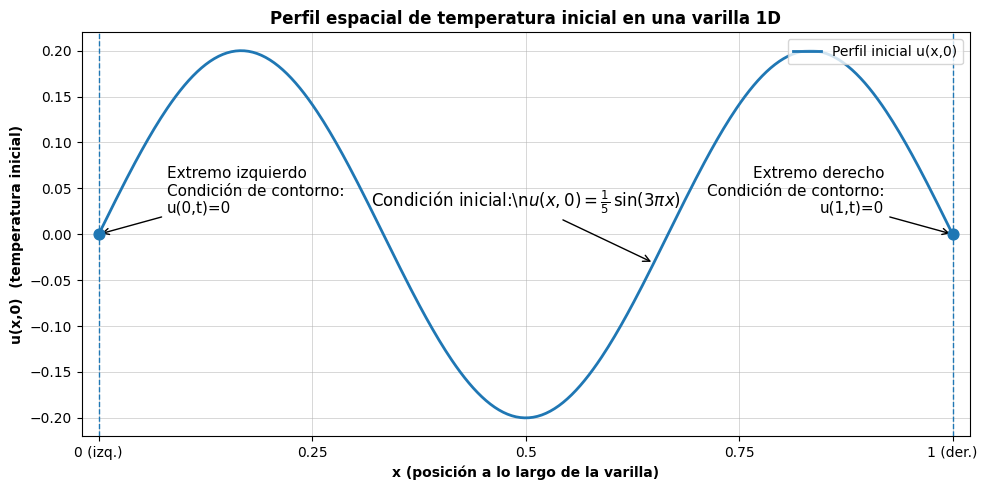

In [ ]:


# =========================
# Reproducibilidad y dominio
# =========================
random.seed(42)
np.random.seed(42)

# Flag para elegir ansatz:
# True -> u(x,t) = (1/5) * sin(3πx) * h(t)  con h(t)=1 + t*r(t)  (BC e IC correctas por construcción)
# False -> u(x,t) = x(1-x) * g(x,t)         (BC exactas, modo libre)
MODE_AWARE_ANSATZ = True

# Gráfica de la condición inicial (1D) para referencia
n_puntos = 400
x_grid = np.linspace(0.0, 1.0, n_puntos)
u_inicial = (1/5) * np.sin(3*np.pi * x_grid)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, u_inicial, linewidth=2, label="Perfil inicial u(x,0)")
plt.scatter([0,1], [0,0], s=60, zorder=5)
plt.annotate("Extremo izquierdo\nCondición de contorno:\nu(0,t)=0",
             xy=(0,0), xytext=(0.08, 0.02),
             arrowprops=dict(arrowstyle="->", lw=1),
             fontsize=11, ha="left", va="bottom")
plt.annotate("Extremo derecho\nCondición de contorno:\nu(1,t)=0",
             xy=(1,0), xytext=(0.92, 0.02),
             arrowprops=dict(arrowstyle="->", lw=1),
             fontsize=11, ha="right", va="bottom")
plt.annotate(r"Condición inicial:\n$u(x,0)=\frac{1}{5}\,\sin(3\pi x)$",
             xy=(0.65, (1/5)*np.sin(3*np.pi*0.65)), xytext=(0.5, .02),
             arrowprops=dict(arrowstyle="->", lw=1),
             fontsize=12, ha="center", va="bottom")

plt.xlabel("x (posición a lo largo de la varilla)", fontweight="bold")
plt.ylabel("u(x,0)  (temperatura inicial)", fontweight="bold")
plt.title("Perfil espacial de temperatura inicial en una varilla 1D", fontweight="bold")
plt.xlim(-0.02, 1.02)
plt.xticks([0.0, 0.25, 0.5, 0.75, 1.0], ["0 (izq.)", "0.25", "0.5", "0.75", "1 (der.)"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)
plt.grid(True, linewidth=0.7, alpha=0.5)
plt.legend(loc="upper right")
plt.tight_layout()

In [ ]:



# =========================
# Primitivas NumPy-friendly (renombradas para que el árbol imprima 'sin', 'cos', 'mul', etc.)
# =========================
def np_add(a, b): return a + b
def np_sub(a, b): return a - b
def np_mul(a, b): return a * b
def np_neg(a):    return -a
def np_sin(a):    return np.sin(a)
def np_cos(a):    return np.cos(a)

def times_pi(a):  return a * math.pi
def times_3(a):   return a * 3.0

def safe_exp_np(x, cap=20.0):
    return np.exp(cap * np.tanh(x / cap))

def sin_kpi_x_1(x): return np.sin(1.0 * math.pi * x)
def sin_kpi_x_2(x): return np.sin(2.0 * math.pi * x)
def sin_kpi_x_3(x): return np.sin(3.0 * math.pi * x)

# Renombrar __name__ para que el string del individuo use 'sin', 'cos', 'mul', etc.
np_add.__name__ = 'add'
np_sub.__name__ = 'sub'
np_mul.__name__ = 'mul'
np_neg.__name__ = 'neg'
np_sin.__name__ = 'sin'
np_cos.__name__ = 'cos'
safe_exp_np.__name__ = 'safe_exp'
times_pi.__name__ = 'times_pi'
times_3.__name__ = 'times_3'
sin_kpi_x_1.__name__ = 'sin_kpi_x_1'
sin_kpi_x_2.__name__ = 'sin_kpi_x_2'
sin_kpi_x_3.__name__ = 'sin_kpi_x_3'

pset = gp.PrimitiveSet('MAIN', 2)  # args: x, t
pset.renameArguments(ARG0='x')
pset.renameArguments(ARG1='t')

pset.addPrimitive(np_add, 2)
pset.addPrimitive(np_sub, 2)
pset.addPrimitive(np_mul, 2)
pset.addPrimitive(np_neg, 1)
pset.addPrimitive(np_sin, 1)
pset.addPrimitive(np_cos, 1)

pset.addPrimitive(times_pi, 1)
pset.addPrimitive(times_3, 1)

# Puedes activar safe_exp si quieres facilitar decaimiento estable:
# pset.addPrimitive(safe_exp_np, 1)

# Senoides espaciales (útiles si usas x(1-x)g)
pset.addPrimitive(sin_kpi_x_1, 1)
pset.addPrimitive(sin_kpi_x_2, 1)
pset.addPrimitive(sin_kpi_x_3, 1)

# Terminales fijas
pset.addTerminal(math.pi, name="pi")
pset.addTerminal(0.2, name="one_fifth")
pset.addTerminal(1.0, name="one")
pset.addTerminal(2.0, name="two")
pset.addTerminal(3.0, name="three")

# Constantes efímeras
pset.addEphemeralConstant("U55", partial(random.uniform, -2.0, 2.0))
pset.addEphemeralConstant("U11", partial(random.uniform, -0.5, 0.5))
pset.addEphemeralConstant("G01", partial(random.gauss, 0.0, 0.5))



In [ ]:
# =========================
# Tipos evolutivos
# =========================
try:
    creator.FitnessMin
except AttributeError:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
try:
    creator.Individual
except AttributeError:
    creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register('expr', gp.genHalfAndHalf, pset=pset, min_=2, max_=3)
toolbox.register('individual', tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register("compile", gp.compile, pset=pset)



In [ ]:
# =========================
# Parámetros PDE y malla
# =========================
alpha = 1.0
t_min = 1e-3
Nx, Nt = 64, 64
X = np.linspace(0.0, 1.0, Nx)
T = np.linspace(t_min, 0.15, Nt)
XX, TT = np.meshgrid(X, T, indexing='xy')  # (Nt, Nx)
dx = X[1] - X[0]
dt = T[1] - T[0]

# IC exacta en t=0
X_ic = X.copy()
target_ic = (1.0/5.0) * np.sin(3*np.pi*X_ic)


In [ ]:

# =========================
# Evaluación
# =========================
def evaluar(ind):
    try:
        base_fun = toolbox.compile(expr=ind)  # g(x,t) o r(x,t)/h(x,t) según ansatz
    except Exception:
        return (1e9,)

    if MODE_AWARE_ANSATZ:
        # u(x,t) = 0.2 * sin(3πx) * h(t),  h(t) = 1 + t * r(t); r(t) = base_fun(0,t)
        def h_time_only(t):
            return 1.0 + t * base_fun(0.0, t)   # fuerza h(0)=1
        def u(x, t):
            return 0.2 * np.sin(3.0*math.pi*x) * h_time_only(t)
    else:
        # u(x,t) = x(1-x) * g(x,t)
        def u(x, t):
            return x * (1.0 - x) * base_fun(x, t)

    try:
        U = u(XX, TT)
        if not np.all(np.isfinite(U)) or np.any(np.abs(U) > 1e8):
            return (1e8,)

        # Derivadas centradas en interior
        Ut  = (U[2:,1:-1] - U[:-2,1:-1]) / (2*dt)
        Uxx = (U[1:-1,2:] - 2.0*U[1:-1,1:-1] + U[1:-1,:-2]) / (dx*dx)

        resid = Ut - alpha * Uxx
        if not np.all(np.isfinite(resid)) or np.any(np.abs(resid) > 1e8):
            return (1e8,)
        mse_res = float(np.mean(resid*resid))

        # Condición inicial en t=0
        U_init = u(X_ic, 0.0)
        if not np.all(np.isfinite(U_init)) or np.any(np.abs(U_init) > 1e8):
            return (1e8,)
        ic_pen = float(np.mean((U_init - target_ic)**2))

        # Anti-bloat
        size_pen = 2e-4 * len(ind)

        # Evitar soluciones casi constantes o sólo de t:
        sample_x = np.linspace(0, 1, 8)
        sample_t = np.linspace(0.0, 0.15, 8)
        SX, ST = np.meshgrid(sample_x, sample_t, indexing='xy')
        UU = u(SX, ST)
        var_x = float(np.var(UU, axis=0).mean())
        var_t = float(np.var(UU, axis=1).mean())
        dep_pen = 0.0
        if var_x < 1e-8: dep_pen += 1.0
        if var_t < 1e-10: dep_pen += 0.2

        # IC con mayor peso (h(0)=1 por construcción, debe bajar muy rápido)
        λ_ic = 30.0
        loss = mse_res + λ_ic*ic_pen + size_pen + dep_pen
        return (loss,)
    except Exception:
        return (1e8,)

toolbox.register("evaluate", evaluar)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("expr_mut", gp.genFull, min_=1, max_=4)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr_mut, pset=pset)

# Limitar altura para controlar bloat
toolbox.decorate("mate", gp.staticLimit(key=operator.attrgetter("height"), max_value=16))
toolbox.decorate("mutate", gp.staticLimit(key=operator.attrgetter("height"), max_value=16))

gen	nevals	avg  	std    	min    	max    
0  	400   	262.8	862.415	30.7193	14372.4
1  	275   	160.609	90.8112	29.6342	1292.55
2  	295   	326.828	2741.61	29.6342	53802.2
3  	312   	455.889	5049.35	27.9033	100705 
4  	287   	178.99 	561.495	27.9033	9817.5 
5  	293   	440.94 	5482.02	30.5989	109603 
6  	284   	187.214	831.385	22.0834	14556.7
7  	303   	141.702	376.311	22.0834	4919.84
8  	288   	447.876	5865.38	22.0834	116949 
9  	286   	100.057	309.847	22.0834	5022.7 
10 	291   	150.442	790.247	21.8736	13400.5
11 	291   	301.497	2264.47	21.7257	40864.8
12 	295   	215.102	948.248	21.7257	13016  
13 	285   	138.237	513.29 	21.6762	7041.13
14 	299   	141.387	777.823	20.0164	14476.2
15 	278   	141.545	586.696	16.9741	5489.36
16 	297   	159.102	1115.56	10.663 	20291.8
17 	283   	121.569	466.702	10.663 	5464.18
18 	294   	142.28 	652.631	9.37266	9675.13
19 	279   	130.208	645.272	9.3668 	10368.5
20 	281   	1140.15	17433.9	9.3668 	345955 
21 	268   	331.18 	2785.5 	9.3668 	39339.7
22 	269   	1297

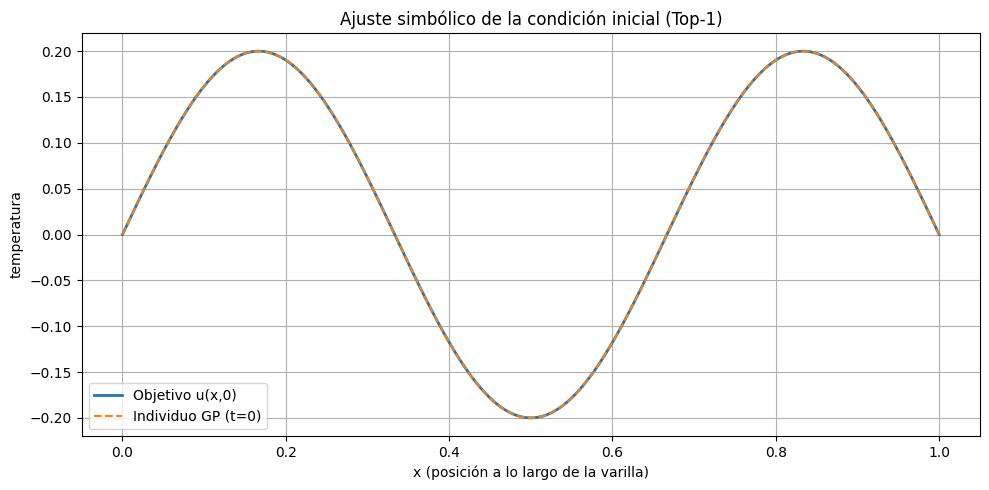

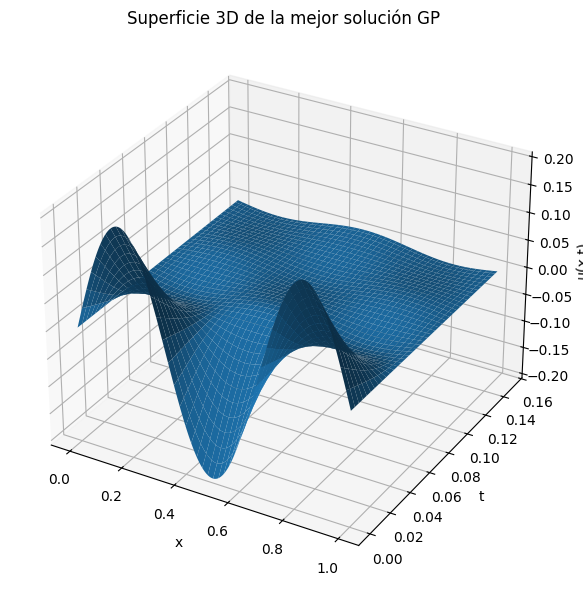

In [ ]:

# =========================
# Evolución: HOF top-k y elitismo efectivo
# =========================
poblacion = toolbox.population(n=400)
hof = tools.HallOfFame(10)

cruza_pob = 0.5
mutacion_pob = 0.45
num_generacion  = 120

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

algorithms.eaSimple(poblacion, toolbox, cxpb=cruza_pob, mutpb=mutacion_pob, ngen=num_generacion,
                    stats=stats, halloffame=hof, verbose=True)

# =========================
# Reporte y visualización
# =========================
def compile_u_from_ind(ind):
    base_fun = toolbox.compile(expr=ind)
    if MODE_AWARE_ANSATZ:
        def h_time_only(t):
            return 1.0 + t * base_fun(0.0, t)
        return lambda x,t: 0.2 * np.sin(3.0*math.pi*x) * h_time_only(t)
    else:
        return lambda x,t: x*(1.0-x) * base_fun(x,t)

def residual_proxy(u_callable):
    U = u_callable(XX, TT)
    Ut  = (U[2:,1:-1] - U[:-2,1:-1]) / (2*dt)
    Uxx = (U[1:-1,2:] - 2.0*U[1:-1,1:-1] + U[1:-1,:-2]) / (dx*dx)
    return float(np.mean((Ut - alpha*Uxx)**2))

print("\n===== TOP-10 HALL OF FAME =====")
for i, ind in enumerate(hof):
    u_i = compile_u_from_ind(ind)
    ic_mse = float(np.mean((u_i(x_grid, 0.0) - u_inicial)**2))
    res_mse = residual_proxy(u_i)
    print(f"[{i}] size={len(ind):3d}  IC_MSE={ic_mse:.6e}  RES_MSE={res_mse:.6e}  expr={ind}")

# Mejor individuo
mejor = hof[0]
u_best = compile_u_from_ind(mejor)

# Comparación IC
y_gp = u_best(x_grid, 0.0)
mse_final_ic = float(((y_gp - u_inicial)**2).mean())
print(f"\nMSE mejor individuo (IC t=0): {mse_final_ic:.8e}")

plt.figure(figsize=(10,5))
plt.plot(x_grid, u_inicial, label="Objetivo u(x,0)", linewidth=2)
plt.plot(x_grid, y_gp, label="Individuo GP (t=0)", linestyle="--")
plt.xlabel("x (posición a lo largo de la varilla)")
plt.ylabel("temperatura")
plt.title("Ajuste simbólico de la condición inicial (Top-1)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Superficie 3D u(x,t)
from mpl_toolkits.mplot3d import Axes3D  # noqa
X3, T3 = np.meshgrid(x_grid, np.linspace(0.0, 0.15, 120), indexing='xy')
U3 = u_best(X3, T3)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X3, T3, U3, linewidth=0, antialiased=True, shade=True)
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_zlabel("u(x,t)")
ax.set_title("Superficie 3D de la mejor solución GP")
plt.tight_layout()
plt.show()


In [ ]:

# =========================
# Expresión simbólica legible (SOLO para mostrar)
# =========================
# Mapeo a SymPy para pretty-print, sin tocar el fitness
sx, st = sympy.symbols('x t', real=True)

def safe_exp_sym(a, cap=20):
    return sympy.exp(cap * sympy.tanh(a / cap))

def sym_times_pi(a): return a*sympy.pi
def sym_times_3(a):  return 3*a

replacements = {
  "add": lambda a,b: a + b,         "sub": lambda a,b: a - b,
  "mul": lambda a,b: a * b,         "neg": lambda a: -a,
  "sin": sympy.sin,                 "cos": sympy.cos,
  "safe_exp": safe_exp_sym,         # si activas safe_exp_np en primitivas
  "times_pi": sym_times_pi,         "times_3": sym_times_3,
  "pi": sympy.pi,
  "one_fifth": sympy.Rational(1,5),
  "one": sympy.Integer(1), "two": sympy.Integer(2), "three": sympy.Integer(3),
  "sin_kpi_x_1": lambda a: sympy.sin(sympy.pi*a),
  "sin_kpi_x_2": lambda a: sympy.sin(2*sympy.pi*a),
  "sin_kpi_x_3": lambda a: sympy.sin(3*sympy.pi*a),
  "x": sx, "t": st
}

try:
    g_sym = sympy.sympify(str(mejor), locals=replacements)
    if MODE_AWARE_ANSATZ:
        # u(x,t) = (1/5) sin(3πx) * [ 1 + t * r(t) ] con r(t) = g_sym(x=0,t)
        r_t = g_sym.subs({sx: sympy.Integer(0)})
        u_sym = sympy.Rational(1,5) * sympy.sin(3*sympy.pi*sx) * (1 + st * r_t)
    else:
        u_sym = sx*(1-sx) * g_sym
    print("\nExpresión simbólica simplificada (Top-1):")
    print(sympy.simplify(u_sym))
except Exception as e:
    print("\nNo se pudo formatear simbólicamente el mejor individuo:", e)


Expresión simbólica simplificada (Top-1):
-(1.9209785304135019*pi*t*(0.999302472755261*sin(0.042636099411586054*pi)*sin(18*pi*t) - sin(pi*(-3*t + 27*sin(2*t)/5 + 3/5 + 3*sqrt(2)*sqrt(sqrt(5) + 5)/4)) + 0.999302472755261*sin(pi*(3*t + 3*(5*pi*sin(1.153658677515304*pi) - 1)*sin(2*pi**2)/5 - 3*sqrt(2)*sqrt(sqrt(5) + 5)/4 - 3/5)) + cos(t) + cos(sin(pi*sin(pi*(-3*t + 3*sin(3*pi**2/5) + 3*pi*sin(0.5833247232097884*pi))))) + cos(sin(pi*sin(sin(pi*t)))) - 0.042606359570637056*pi) - 1)*sin(3*pi*x)/5
